In [1]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

def convert_annotation_to_list(annotation):
    # Collect additional features based on correlation analysis
    additional_features = []
    for feature in annotation:
        # Check if the feature is NaN, if so, append None or an empty list
        if pd.isna(feature):
            additional_features.append(None)  # or append [] for an empty list
        else:
            additional_features.append(feature)
    return additional_features

def split_data(img_dir, ann_file, train_img_dir, val_img_dir, train_ann_file, val_ann_file, val_size=0.2):
    """
    Split the dataset into training and validation sets, and save them into respective directories.

    Parameters:
        img_dir (str): Path to the directory containing the images.
        ann_file (str): Path to the CSV file containing annotations.
        train_img_dir (str): Directory to save training images.
        val_img_dir (str): Directory to save validation images.
        train_ann_file (str): Path to save training annotations CSV file.
        val_ann_file (str): Path to save validation annotations CSV file.
        val_size (float): Proportion of data to be used for validation (default is 0.2).
    """

    # 1. Load annotations CSV
    annotations = pd.read_excel(ann_file)
    annotations = annotations.dropna(subset=['RC骨龄'])
    annotations["RC骨龄"] = pd.to_numeric(annotations["RC骨龄"], errors="coerce")
    
    # 2. Calculate correlation matrix and find features with correlation >= 0.4 with RC骨龄
    correlation_matrix = annotations.corr(numeric_only=True)  # Only numeric columns for correlation
    selected_features = correlation_matrix["RC骨龄"][abs(correlation_matrix["RC骨龄"]) >= 0.4].index.tolist()
    selected_features.remove("RC骨龄")  # Remove RC骨龄 itself
    
    print("Selected features with correlation >= 0.4 with RC:")
    print(selected_features)

    # 2. Add image extensions support (png, bmp, jpg)
    valid_extensions = ['.png', '.bmp', '.jpg']
    
    # Ensure the directories exist
    os.makedirs(train_img_dir, exist_ok=True)
    os.makedirs(val_img_dir, exist_ok=True)
    
    # Ensure the directories for annotations exist
    os.makedirs(os.path.dirname(train_ann_file), exist_ok=True)
    os.makedirs(os.path.dirname(val_ann_file), exist_ok=True)

    # 3. Get all image paths
    image_paths = []
    for idx, row in annotations.iterrows():
        img_id = str(row[0])
        img_path = None
        for ext in valid_extensions:
            possible_img_path = os.path.join(img_dir, img_id + ext)
            if os.path.exists(possible_img_path):
                img_path = possible_img_path
                break
        if img_path:
            image_paths.append((img_path, row))

    # 4. Split data into training and validation sets (randomly)
    train_images, val_images = train_test_split(image_paths, test_size=val_size, random_state=42)

    # 5. Copy images to their respective directories and create the new annotations
    train_annotations = []
    val_annotations = []
    
    # Process training images
    for img_path, annotation in train_images:
        shutil.copy(img_path, train_img_dir)
        id = annotation[0]
        male = annotation['性别']
        bone_age = int(float(annotation['RC骨龄'])*12)
        chronological_age = int(float(annotation['年龄半岁'])*12)
        gut = convert_annotation_to_list(annotation.iloc[181:227])
        pe = convert_annotation_to_list(annotation.iloc[16:22])
         # Collect additional features based on correlation analysis
        additional_features = [float(annotation[feature]) if feature in annotation else None for feature in selected_features]
        all = [id, male, bone_age, chronological_age] + gut + pe + additional_features
        train_annotations.append(all)

    # Process validation images
    for img_path, annotation in val_images:
        shutil.copy(img_path, val_img_dir)
        id = annotation[0]
        male = annotation['性别']
        bone_age = int(float(annotation['RC骨龄'])*12)
        chronological_age = int(float(annotation['年龄半岁'])*12)
        gut = convert_annotation_to_list(annotation.iloc[181:227])
        pe = convert_annotation_to_list(annotation.iloc[16:22])
         # Collect additional features based on correlation analysis
        additional_features = [float(annotation[feature]) if feature in annotation else None for feature in selected_features]
        all = [id, male, bone_age, chronological_age] + gut + pe + additional_features
        val_annotations.append(all)
    
    # 6. Save the new annotations as CSV files
    columns = ['ID', 'Gender', 'Boneage', 'Chronological_age']  # 手动添加前四列
    gut_columns = [f'Gut_{i}' for i in range(len(gut))]  # 自动生成肠道菌群数据列名
    pe_columns = [f'PE_{i}' for i in range(len(pe))]  # 自动生成运动表现数据列名
    additional_columns = selected_features  # 自动生成与RC骨龄相关性大于0.4的特征列名
    all_columns = columns + gut_columns + pe_columns + additional_columns  # 合并所有列名

    train_ann_df = pd.DataFrame(train_annotations, columns=all_columns)
    val_ann_df = pd.DataFrame(val_annotations, columns=all_columns)

    train_ann_df.to_csv(train_ann_file, index=False)
    val_ann_df.to_csv(val_ann_file, index=False)

# Example usage:
img_dir = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/raw/bone_image'  # 图片所在目录
ann_file = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/raw/data_all.xlsx'  # 注释文件路径
train_img_dir = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/train'  # 存储训练集图像的目录
val_img_dir = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/val'  # 存储验证集图像的目录
train_ann_file = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/annotations/train_ann.csv'  # 训练集注释文件
val_ann_file = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/annotations/val_ann.csv'  # 验证集注释文件

# 调用函数进行数据划分
split_data(img_dir, ann_file, train_img_dir, val_img_dir, train_ann_file, val_ann_file)


/tmp/ipykernel_728054/2253879300.py:32: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  annotations = pd.read_excel(ann_file)


Selected features with correlation >= 0.4 with RC:
['日龄', '年龄整岁', '年龄半岁', '身高', '体重', '10米跑', '立定跳远', '掷球', '平衡木', '胸围', '握力', '9. TBW (Total Body Water)', '12. ICW (Intracellular Water)', '15. ECW (Extracellular Water)', '18. Protein', '21. Minerals', '30. FFM (Fat Free Mass)', '33. SMM (Skeletal Muscle Mass)', '144. BMC (Bone Mineral Content)', 'RSA']


In [2]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

ann_file = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/raw/data_all.xlsx'  # 注释文件路径
train_ann_file = '/private/workspace/cyt/bone_age_assessment/data/data_yuwei/annotations/train_ann.csv'  # 训练集注释文件

# 1. Load annotations CSV
annotations_raw = pd.read_excel(ann_file)
annotations_filter = pd.read_csv(train_ann_file)

# 验证过滤数据与原数据的一致性
row_raw = annotations_raw[annotations_raw['编号'] == 1126]
row_raw.iloc[:, 16:22]
row_filter = annotations_filter[annotations_filter['ID'] == 1126]
row_filter.iloc[:, 50:56]

/tmp/ipykernel_963209/855182478.py:10: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  annotations_raw = pd.read_excel(ann_file)


,PE_0,PE_1,PE_2,PE_3,PE_4,PE_5
0,17.0,9.0,90.0,4.5,6.5,23.4


In [ ]:
pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.width', None)  # 自动调整显示宽度
pd.set_option('display.max_colwidth', None)  # 让列内容完整显示
print(annotations_filter[annotations_filter['ID'] == 323])

      ID  Gender  Boneage  Chronological_age  Gut_0  Gut_1  Gut_2  Gut_3  \
307  323       2       70                 48  694.0   40.0   21.6   85.0   

     Gut_4  Gut_5  Gut_6  Gut_7  Gut_8  Gut_9  Gut_10  Gut_11  Gut_12  Gut_13  \
307    3.7  523.0  250.0    5.5   5.59    0.0    0.37    0.55    0.15     0.0   

     Gut_14  Gut_15  Gut_16  Gut_17  Gut_18  Gut_19  Gut_20  Gut_21  Gut_22  \
307    20.9     0.0    40.0    8.49   267.0   501.0   836.0   394.8   129.0   

     Gut_23  Gut_24  Gut_25  Gut_26  Gut_27  Gut_28  Gut_29  Gut_30  Gut_31  \
307     0.0     6.9    77.2    4.84   36.71    0.98     0.0     0.0    1.46   

     Gut_32  Gut_33  Gut_34  Gut_35  Gut_36  Gut_37  Gut_38  Gut_39  Gut_40  \
307     0.0     0.0    13.2     2.3     0.0   119.9     7.7    68.2    68.5   

     Gut_41  Gut_42  Gut_43  Gut_44  Gut_45  PE_0  PE_1  PE_2  PE_3  PE_4  \
307    81.0    35.3    68.6   108.3     4.8  14.8   8.5  97.0   3.1   8.8   

     PE_5      日龄  年龄整岁  年龄半岁     身高    体重  10米跑  立定

In [6]:
annotations_filter[annotations_filter['ID'] == 323].iloc[:, 56:].shape

(1, 20)

缺失值数量：
ID                                   0
Gender                               0
Boneage                              0
Chronological_age                    0
Gut_0                               81
Gut_1                               81
Gut_2                               81
Gut_3                               81
Gut_4                               81
Gut_5                               81
Gut_6                               81
Gut_7                               81
Gut_8                               81
Gut_9                               81
Gut_10                             184
Gut_11                             184
Gut_12                              81
Gut_13                              81
Gut_14                              81
Gut_15                              81
Gut_16                              81
Gut_17                              81
Gut_18                              81
Gut_19                              81
Gut_20                              81
Gut_21            

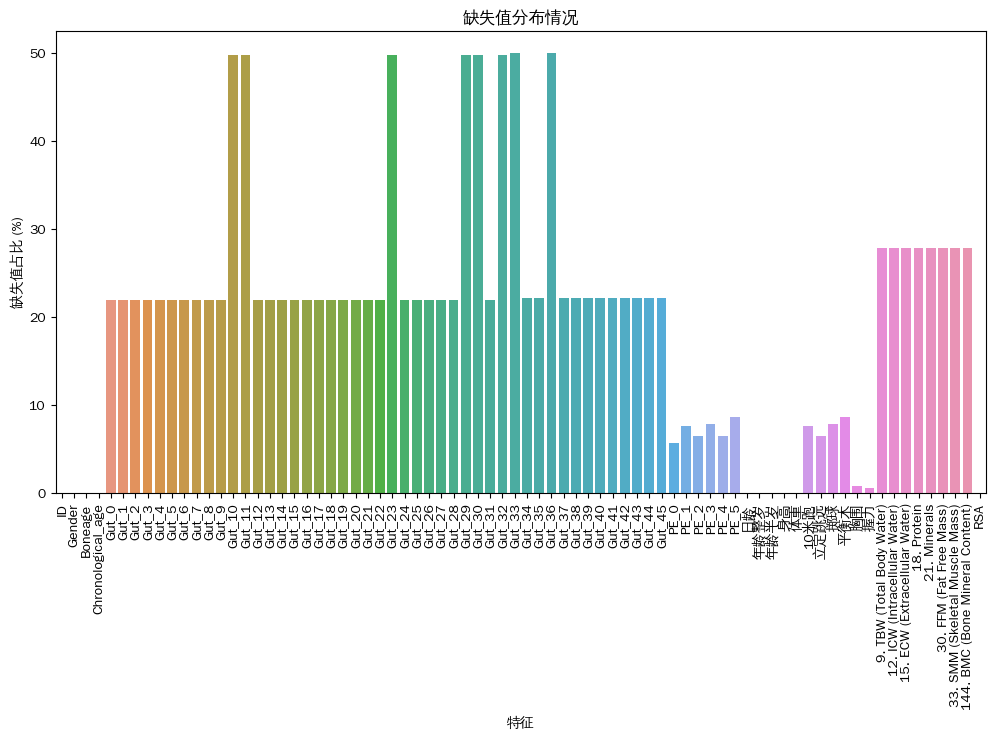

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# # 解决 Matplotlib 中文乱码问题
# 指定字体路径（请检查你的具体字体文件路径）
font_path = "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc"  # 适用于 Noto Sans CJK SC

# 加载字体
font_prop = fm.FontProperties(fname=font_path)

# 设置 Matplotlib 使用这个字体
plt.rcParams["font.family"] = font_prop.get_name()

pd.options.display.max_rows = None  # 显示所有行
pd.options.display.max_columns = None  # 显示所有列


# 2. 统计每一列的缺失值数量
missing_data = annotations_filter.isna().sum()

# 3. 计算每列的缺失率（缺失值数量 / 总行数）
missing_rate = missing_data / len(annotations_filter) * 100

# 4. 显示缺失值数量和缺失率
print("缺失值数量：")
print(missing_data)
print("\n缺失值占比（%）：")
print(missing_rate)

# 5. 可视化缺失值分布
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_rate.index, y=missing_rate.values)
plt.xticks(rotation=90)
plt.xlabel('特征')
plt.ylabel('缺失值占比 (%)')
plt.title('缺失值分布情况')
plt.show()


In [46]:
len(annotations_filter.iloc[:, 56:-1].dropna())

253

In [47]:
len(annotations_filter.dropna())

121

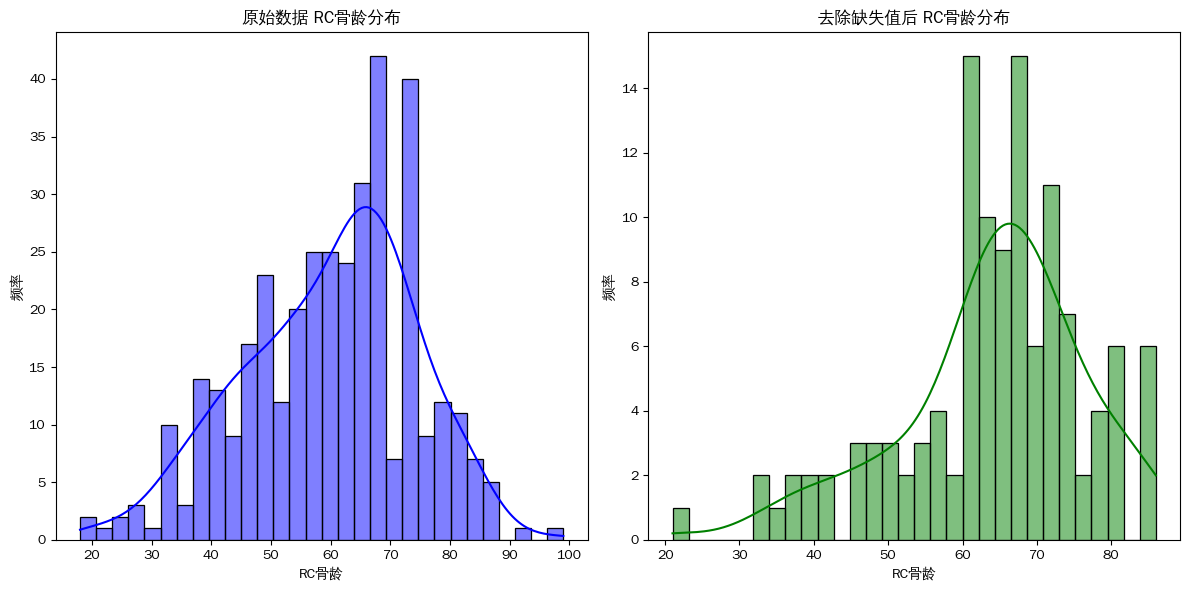

In [50]:
# 假设 annotations_filter 是原始的 DataFrame
# 绘制原始数据骨龄分布图
plt.figure(figsize=(12, 6))

# 1. 原始数据的 RC骨龄分布
plt.subplot(1, 2, 1)
sns.histplot(annotations_filter['Boneage'], bins=30, kde=True, color='blue')
plt.title('原始数据 RC骨龄分布')
plt.xlabel('RC骨龄')
plt.ylabel('频率')

# 2. 去除缺失值后的数据的 RC骨龄分布
annotations_filtered = annotations_filter.dropna()
plt.subplot(1, 2, 2)
sns.histplot(annotations_filtered['Boneage'], bins=30, kde=True, color='green')
plt.title('去除缺失值后 RC骨龄分布')
plt.xlabel('RC骨龄')
plt.ylabel('频率')

# 显示图像
plt.tight_layout()
plt.show()
